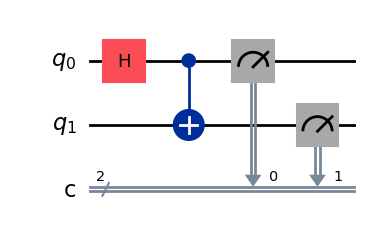

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# 1. Initialize a 2-qubit circuit (optionally add 2 classical bits for measurement)
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)

# 2. Add measurement so the simulator has data to collect
qc.measure([0, 1], [0, 1])

# 3. Draw the circuit locally using Matplotlib
# Note: Ensure 'matplotlib' and 'pydot' or 'pillow' are installed in your quantum_env
qc.draw(output='mpl')



In [4]:
from qiskit.quantum_info import Pauli

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observables = (ZZ, ZI, IZ, XX, XI, IX)
print("Observables Tuple:", observables)

Observables Tuple: (Pauli('ZZ'), Pauli('ZI'), Pauli('IZ'), Pauli('XX'), Pauli('XI'), Pauli('IX'))


In [6]:
from qiskit_aer.primitives import Estimator

# Match the number of circuits to the number of observables
circuits = [qc] * len(observables)

# Initialize the local Aer Estimator and execute
estimator = Estimator()
job = estimator.run(circuits, observables)
result = job.result()

# Extract expectation values
values = result.values
print("Expectation Values:", values)

Expectation Values: [ 1.          0.0625      0.0625      1.         -0.05078125 -0.05078125]


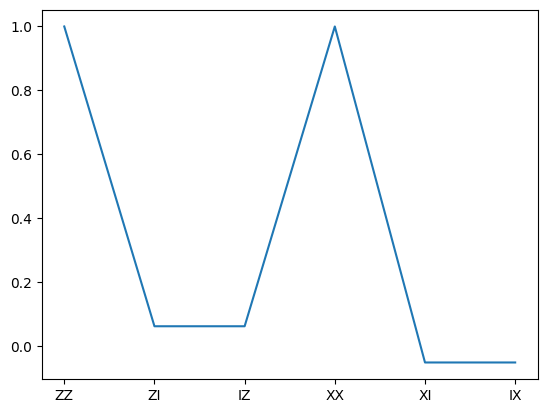

In [7]:
import matplotlib.pyplot as plt

data = ("ZZ", "ZI", "IZ", "XX", "XI", "IX")
values = job.result().values

plt.plot(data, values)
plt.show()